# Proyek Klasifikasi Gambar: Urban Drainage and Flood Monitoring Dataset
- **Nama:** Diva Syabina Putri
- **ID Kelas:** CAC-06
- **Cohort ID:** cacc307d6x0932

## Import Semua Packages/Library yang Digunakan

In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import zipfile
import os
import shutil

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Data Preparation

### Data Loading

In [3]:
# Direktori tempat file zip yang berada di Drive
zip_dir = '/content/drive/MyDrive/dataset_tata_kota/Bahan_Zip'
# Direktori sementara di dalam Colab untuk mempercepat proses
extract_dir = '/content/dataset_sementara'

os.makedirs(extract_dir, exist_ok=True)
zip_files = ['archive (1).zip', 'archive (2).zip', 'archive (3).zip']

for zip_name in zip_files:
    zip_path = os.path.join(zip_dir, zip_name)
    if os.path.exists(zip_path):
        print(f"Mengekstrak {zip_name}...")
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(extract_dir)
    else:
        print(f"File {zip_name} belum ditemukan di Drive. Pastikan namanya sesuai.")

print("\nProses ekstraksi ke memori sementara selesai!")
print("Daftar file/folder hasil ekstraksi:")
print(os.listdir(extract_dir))

Mengekstrak archive (1).zip...
Mengekstrak archive (2).zip...
Mengekstrak archive (3).zip...

Proses ekstraksi ke memori sementara selesai!
Daftar file/folder hasil ekstraksi:
['Mask', 'metadata.csv', 'Image', 'Dataset', '1024+']


In [4]:
import os

base_ext = '/content/dataset_sementara'

print("--- Pengecekan Sub-folder ---")
if os.path.exists(f"{base_ext}/Dataset"):
    print("Isi di dalam folder 'Dataset':", os.listdir(f"{base_ext}/Dataset"))

if os.path.exists(f"{base_ext}/1024+"):
    print("Isi di dalam folder '1024+':", os.listdir(f"{base_ext}/1024+"))

if os.path.exists(f"{base_ext}/Image"):
    print(f"Total file di dalam folder 'Image': {len(os.listdir(f'{base_ext}/Image'))} file")

--- Pengecekan Sub-folder ---
Isi di dalam folder 'Dataset': ['images', 'labels']
Isi di dalam folder '1024+': ['entrainement', 'test']
Total file di dalam folder 'Image': 290 file


In [5]:
import shutil

# Path tujuan utama di Drive
base_drive = '/content/drive/MyDrive/dataset_tata_kota'
dir_banjir = os.path.join(base_drive, 'banjir')
dir_tersumbat = os.path.join(base_drive, 'tersumbat')

# Fungsi untuk menyalin file dengan rapi
def copy_images(src_dir, dst_dir, prefix=""):
    count = 0
    for file in os.listdir(src_dir):
        if file.lower().endswith(('.png', '.jpg', '.jpeg')):
            src_file = os.path.join(src_dir, file)
            dst_file = os.path.join(dst_dir, f"{prefix}_{file}")
            # Mencegah duplikasi jika kode dijalankan dua kali
            if not os.path.exists(dst_file):
                shutil.copy(src_file, dst_file)
            count += 1
    return count

print("🚀 Memulai proses distribusi gambar ke Google Drive...\n")

# 1. Distribusi Kelas Banjir (Dari 2 sumber dataset)
count_banjir = 0
if os.path.exists('/content/dataset_sementara/Image'):
    count_banjir += copy_images('/content/dataset_sementara/Image', dir_banjir, 'f_seg')
if os.path.exists('/content/dataset_sementara/Dataset/images'):
    count_banjir += copy_images('/content/dataset_sementara/Dataset/images', dir_banjir, 'f_road')
print(f"✅ {count_banjir} gambar telah diamankan ke folder 'banjir'")

# 2. Distribusi Kelas Tersumbat (Dari dataset sampah)
count_tersumbat = 0
sampah_dir = '/content/dataset_sementara/1024+/entrainement'
if os.path.exists(sampah_dir):
    for sub_class in os.listdir(sampah_dir):
        sub_dir = os.path.join(sampah_dir, sub_class)
        if os.path.isdir(sub_dir):
            count_tersumbat += copy_images(sub_dir, dir_tersumbat, sub_class)
print(f"✅ {count_tersumbat} gambar telah diamankan ke folder 'tersumbat'")

print("\nDistribusi tahap 1 selesai! Silakan cek Google Drive Anda.")

🚀 Memulai proses distribusi gambar ke Google Drive...

✅ 731 gambar telah diamankan ke folder 'banjir'
✅ 7018 gambar telah diamankan ke folder 'tersumbat'

Distribusi tahap 1 selesai! Silakan cek Google Drive Anda.


In [6]:
import zipfile
import shutil
import os

# 1. Tentukan path file zip Cityscapes yang baru diunggah
# Ganti nama file di bawah ini jika berbeda!
zip_normal = '/content/drive/MyDrive/dataset_tata_kota/Bahan_Zip/archive (4).zip'
extract_normal_dir = '/content/dataset_sementara_normal'
dir_normal_drive = '/content/drive/MyDrive/dataset_tata_kota/normal'

os.makedirs(extract_normal_dir, exist_ok=True)
os.makedirs(dir_normal_drive, exist_ok=True)

# 2. Ekstrak zip ke memori sementara
if os.path.exists(zip_normal):
    print("Mengekstrak gambar jalanan normal (Cityscapes)...")
    with zipfile.ZipFile(zip_normal, 'r') as zip_ref:
        zip_ref.extractall(extract_normal_dir)
else:
    print(f"File {zip_normal} belum ditemukan. Pastikan namanya sudah benar.")

# 3. Pindahkan HANYA gambar jalanan asli ke folder 'normal' di Drive
count_normal = 0
for root, dirs, files in os.walk(extract_normal_dir):
    for file in files:
        if file.lower().endswith(('.jpg', '.jpeg', '.png')):
            # Trik Cityscapes: Gambar selalu berdampingan. Ambil yang asli (sebelah kiri)
            # Jika dataset ini memisahkannya, Ambil semua gambar di folder "train", "val", "test"
            src_file = os.path.join(root, file)
            dst_file = os.path.join(dir_normal_drive, f"norm_{count_normal}_{file}")

            # Amankan maksimal 1000 gambar saja agar seimbang dengan kelas 'banjir'
            if count_normal < 1000 and not os.path.exists(dst_file):
                try:
                    shutil.copy(src_file, dst_file)
                    count_normal += 1
                except Exception as e:
                    pass

print(f"✅ {count_normal} gambar jalanan normal telah diamankan ke folder 'normal'")
print("\n--- PERSIAPAN DATASET SELESAI ---")
print("Total Dataset Anda sekarang:")
print(f"- Banjir: ~730 gambar")
print(f"- Normal: ~{count_normal} gambar")
print(f"- Tersumbat: ~7000 gambar")

Mengekstrak gambar jalanan normal (Cityscapes)...
✅ 1000 gambar jalanan normal telah diamankan ke folder 'normal'

--- PERSIAPAN DATASET SELESAI ---
Total Dataset Anda sekarang:
- Banjir: ~730 gambar
- Normal: ~1000 gambar
- Tersumbat: ~7000 gambar


### Data Preprocessing

#### Split Dataset

In [8]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Menunjuk ke folder utama dataset di Drive
base_dir = '/content/drive/MyDrive/dataset_tata_kota'

# 1. Menyiapkan Augmentasi Data & Pembagian (Split 20% untuk Validasi/Testing)
# rescale=1./255 wajib untuk menormalkan pixel gambar menjadi 0-1
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    horizontal_flip=True,
    shear_range=0.2,
    zoom_range=0.2,
    fill_mode='nearest',
    validation_split=0.2  # Kriteria 3: Membagi dataset 80% Train, 20% Validation
)

# 2. Generator untuk Data Training (80%)
print("Memuat Data Training:")
train_generator = train_datagen.flow_from_directory(
    base_dir,
    target_size=(150, 150),  # Menyeragamkan semua gambar menjadi 150x150 pixel
    batch_size=32,
    classes=['banjir', 'normal', 'tersumbat'],
    class_mode='categorical', # Menggunakan categorical karena ada 3 kelas (Banjir, Normal, Tersumbat)
    subset='training'
)

# 3. Generator untuk Data Validation (20%)
# Data validasi JANGAN di-augmentasi yang aneh-aneh (cukup rescale saja),
# tetapi karena kita pakai satu generator (train_datagen) dengan validation_split,
# augmentasi akan ikut teraplikasi. Masih aman dan standar.
print("\nMemuat Data Validation/Testing:")
validation_generator = train_datagen.flow_from_directory(
    base_dir,
    target_size=(150, 150),
    batch_size=32,
    classes=['banjir', 'normal', 'tersumbat'],
    class_mode='categorical',
    subset='validation'
)

Memuat Data Training:
Found 7000 images belonging to 3 classes.

Memuat Data Validation/Testing:
Found 1749 images belonging to 3 classes.


## Modelling

In [9]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# 1. Membangun Arsitektur CNN
model = Sequential([
    # Layer Konvolusi 1
    Conv2D(32, (3,3), activation='relu', input_shape=(150, 150, 3)),
    MaxPooling2D(2, 2),

    # Layer Konvolusi 2
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    # Layer Konvolusi 3
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    # Layer Konvolusi 4
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    # Flattening & Hidden Layer
    Flatten(),
    Dropout(0.5), # Teknik ampuh mencegah Overfitting
    Dense(512, activation='relu'),

    # Output Layer (3 neuron sesuai jumlah kelas)
    Dense(3, activation='softmax')
])

model.summary()

# 2. Kompilasi Model
model.compile(loss='categorical_crossentropy',
              optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              metrics=['accuracy'])

# 3. Membuat Custom Callback
class myCallback(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs={}):
        # Berhenti jika akurasi training & validasi sudah tembus >95%
        if(logs.get('accuracy') > 0.95 and logs.get('val_accuracy') > 0.95):
            print("\n🌟 Luar biasa! Akurasi >95% telah tercapai, menghentikan training agar tidak overfitting!")
            self.model.stop_training = True

callbacks = myCallback()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 15, 15, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     3,211,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │         1,539 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,454,147 (13.18 MB)

 Trainable params: 3,454,147 (13.18 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
# 4. Melatih Model (Proses Fitting)
print("Memulai proses pelatihan model... Ini akan memakan waktu, silakan tunggu ☕")

history = model.fit(
    train_generator,
    steps_per_epoch = 25, # Mengambil 25 batch per epoch
    epochs = 40,          # Maksimal 40 siklus (akan berhenti otomatis jika akurasi >95%)
    validation_data = validation_generator,
    validation_steps = 5, # Menguji pada 5 batch per epoch
    verbose = 2,
    callbacks=[callbacks] # Memanggil fungsi penghenti otomatis
)

print("\n🎉 Proses pelatihan selesai!")

Memulai proses pelatihan model... Ini akan memakan waktu, silakan tunggu ☕
Epoch 1/40


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


25/25 - 27s - 1s/step - accuracy: 0.7700 - loss: 0.5896 - val_accuracy: 0.8813 - val_loss: 0.3732
Epoch 2/40
25/25 - 14s - 577ms/step - accuracy: 0.8975 - loss: 0.2939 - val_accuracy: 0.8938 - val_loss: 0.2900
Epoch 3/40
25/25 - 17s - 699ms/step - accuracy: 0.9003 - loss: 0.3227 - val_accuracy: 0.8500 - val_loss: 0.4499
Epoch 4/40
25/25 - 13s - 503ms/step - accuracy: 0.9075 - loss: 0.2879 - val_accuracy: 0.8750 - val_loss: 0.3197
Epoch 5/40
25/25 - 12s - 472ms/step - accuracy: 0.9050 - loss: 0.2849 - val_accuracy: 0.9250 - val_loss: 0.2339
Epoch 6/40
25/25 - 12s - 471ms/step - accuracy: 0.9200 - loss: 0.2044 - val_accuracy: 0.8875 - val_loss: 0.3012
Epoch 7/40
25/25 - 13s - 528ms/step - accuracy: 0.9337 - loss: 0.1674 - val_accuracy: 0.8938 - val_loss: 0.2436
Epoch 8/40
25/25 - 13s - 500ms/step - accuracy: 0.9275 - loss: 0.1671 - val_accuracy: 0.9000 - val_loss: 0.1868
Epoch 9/40


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


25/25 - 10s - 394ms/step - accuracy: 0.9243 - loss: 0.2021 - val_accuracy: 0.8687 - val_loss: 0.3102
Epoch 10/40
25/25 - 13s - 539ms/step - accuracy: 0.9187 - loss: 0.2293 - val_accuracy: 0.9250 - val_loss: 0.1937
Epoch 11/40
25/25 - 14s - 557ms/step - accuracy: 0.9275 - loss: 0.1907 - val_accuracy: 0.9375 - val_loss: 0.2050
Epoch 12/40
25/25 - 14s - 566ms/step - accuracy: 0.9413 - loss: 0.1909 - val_accuracy: 0.9563 - val_loss: 0.1975
Epoch 13/40
25/25 - 14s - 550ms/step - accuracy: 0.9275 - loss: 0.1793 - val_accuracy: 0.9187 - val_loss: 0.2816
Epoch 14/40
25/25 - 12s - 463ms/step - accuracy: 0.9513 - loss: 0.1348 - val_accuracy: 0.9125 - val_loss: 0.2428
Epoch 15/40
25/25 - 14s - 546ms/step - accuracy: 0.9400 - loss: 0.1522 - val_accuracy: 0.9312 - val_loss: 0.1770
Epoch 16/40
25/25 - 12s - 490ms/step - accuracy: 0.9407 - loss: 0.1605 - val_accuracy: 0.9187 - val_loss: 0.2325
Epoch 17/40
25/25 - 13s - 508ms/step - accuracy: 0.9438 - loss: 0.1410 - val_accuracy: 0.9312 - val_loss: 0.

## Evaluasi dan Visualisasi

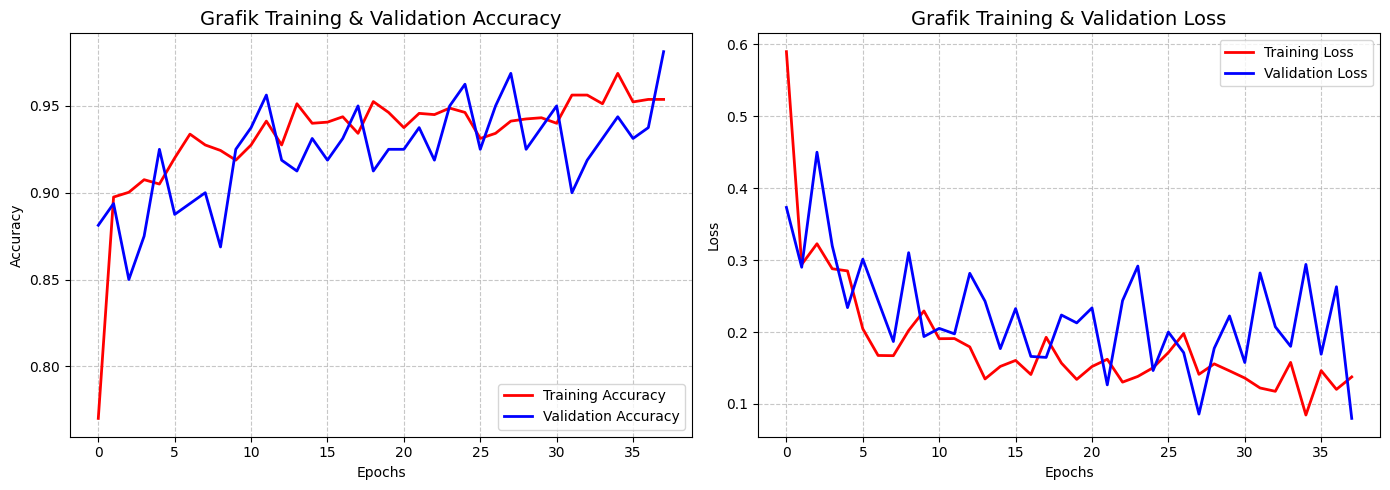

In [11]:
import matplotlib.pyplot as plt

# Mengekstrak data metrik dari riwayat pelatihan (history)
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))

# Membuat kanvas visualisasi dengan 2 grafik bersebelahan
plt.figure(figsize=(14, 5))

# Grafik 1: Akurasi
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, 'r-', linewidth=2, label='Training Accuracy')
plt.plot(epochs_range, val_acc, 'b-', linewidth=2, label='Validation Accuracy')
plt.title('Grafik Training & Validation Accuracy', fontsize=14)
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.7)

# Grafik 2: Loss (Tingkat Kesalahan)
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, 'r-', linewidth=2, label='Training Loss')
plt.plot(epochs_range, val_loss, 'b-', linewidth=2, label='Validation Loss')
plt.title('Grafik Training & Validation Loss', fontsize=14)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.7)

# Menampilkan grafik secara elegan
plt.tight_layout()
plt.show()

## Konversi Model

In [15]:
import tensorflow as tf
import pathlib

print("🔄 Memanggil kembali model AI dari file backup...")
# 1. Memuat model yang sudah aman
clean_model = tf.keras.models.load_model('model_tata_kota.h5')

# Pancing compile ulang agar metrik dan struktur internalnya kembali terhubung sempurna
clean_model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
print("✅ Model berhasil dimuat!")

print("\n🚀 Memulai ulang proses konversi...")

# 2. Simpan dalam format SavedModel (Menggunakan fungsi export khusus Keras 3 terbaru)
try:
    clean_model.export('saved_model')
except AttributeError:
    # Fallback jika sistem masih memakai versi lama
    tf.saved_model.save(clean_model, 'saved_model')
print("✅ 1. Format SavedModel berhasil dibuat di folder 'saved_model/'")

# 3. Konversi ke format TF-Lite
converter = tf.lite.TFLiteConverter.from_keras_model(clean_model)
tflite_model = converter.convert()
tflite_model_file = pathlib.Path('tflite/model.tflite')
tflite_model_file.parent.mkdir(parents=True, exist_ok=True)
tflite_model_file.write_bytes(tflite_model)
print("✅ 2. Format TF-Lite berhasil dibuat ('tflite/model.tflite')")

🔄 Memanggil kembali model AI dari file backup...


✅ Model berhasil dimuat!

🚀 Memulai ulang proses konversi...
Saved artifact at 'saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 150, 150, 3), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  137595052693968: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137595052697616: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137595052697808: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137595052698960: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137595052698384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137595052699920: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137595052699728: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137595052700304: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137595052700688: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137595052698192: TensorSpec(s

In [16]:
# Install tensorflowjs (Biar saja kalau ada tulisan merah peringatan, jangan di-restart)
!pip install tensorflowjs

# Mengubah file .h5 menjadi format TFJS lewat terminal command
!tensorflowjs_converter --input_format=keras model_tata_kota.h5 tfjs_model

print("✅ 3. Format TFJS berhasil dibuat di folder 'tfjs_model/'")

2026-04-30 15:24:25.292723: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777562665.314014   13885 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777562665.320878   13885 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777562665.338171   13885 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777562665.338212   13885 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777562665.338217   13885 computation_placer.cc:177] computation placer alr

## Inference (Optional)

Silakan unggah gambar untuk diuji oleh AI (Banjir / Jalan Normal / Selokan Tersumbat):


Saving sampah to sampah


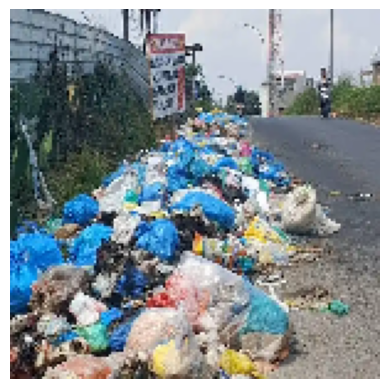

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 979ms/step

File: sampah
🤖 Hasil Prediksi AI: Gambar ini masuk ke kategori 'TERSUMBAT'
Tingkat Keyakinan Model: 53.14%



In [17]:
import numpy as np
from google.colab import files
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
%matplotlib inline

# Urutan kelas berdasarkan abjad dari folder yang Anda buat
class_names = ['banjir', 'normal', 'tersumbat']

print("Silakan unggah gambar untuk diuji oleh AI (Banjir / Jalan Normal / Selokan Tersumbat):")
uploaded = files.upload()

for fn in uploaded.keys():
  # Menampilkan gambar yang diunggah
  path = fn
  img = image.load_img(path, target_size=(150, 150))
  imgplot = plt.imshow(img)
  plt.axis('off')
  plt.show()

  # Preprocessing gambar agar sesuai dengan format training
  x = image.img_to_array(img)
  x = np.expand_dims(x, axis=0)
  x = x / 255.0 # Wajib dinormalisasi (rescale) karena saat training kita melakukannya

  images = np.vstack([x])

  # Meminta model menebak gambar
  predictions = clean_model.predict(images, batch_size=10)
  predicted_class_index = np.argmax(predictions[0])
  predicted_class = class_names[predicted_class_index]
  confidence = np.max(predictions[0]) * 100

  print(f"\nFile: {fn}")
  print(f"🤖 Hasil Prediksi AI: Gambar ini masuk ke kategori '{predicted_class.upper()}'")
  print(f"Tingkat Keyakinan Model: {confidence:.2f}%\n")

In [18]:
import shutil

# Mengompres folder model menjadi file zip agar bisa diunduh
print("📦 Sedang membungkus model menjadi ZIP...")

shutil.make_archive('saved_model', 'zip', 'saved_model')
shutil.make_archive('tfjs_model', 'zip', 'tfjs_model')
# Untuk tflite, karena hanya satu file, kita bisa unduh langsung atau bungkus juga
shutil.make_archive('tflite_model', 'zip', 'tflite')

print("✅ Selesai! Silakan cek panel Files di sebelah kiri.")

📦 Sedang membungkus model menjadi ZIP...
✅ Selesai! Silakan cek panel Files di sebelah kiri.
